In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Aug 19 23:11 2025

@author: shanku
"""

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split  # For splitting data

np.random.seed(1836)  # to make this code example reproducible
m = 30  # number of instances


# column vector for independent variable (input) M x 1
X = 3 * np.random.rand(m, 1)
# dependent variable with cubic relationship and noise (output)
y = 3 + 0.5 * X + 1.5 * X**2 - 0.5 * X**3 + 0.3 * np.random.randn(m, 1)

# --- Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1836
)

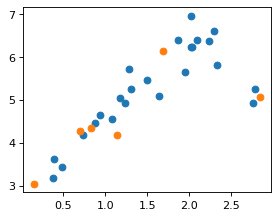

In [2]:
plt.figure(figsize=(4, 3), dpi=80)
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

In [3]:
# Define a function for adding a dummy feature (intercept term)
# does not need as polynomial started from 0 degree
# def add_dummy_feature(X):
#     return np.c_[np.ones((X.shape[0], 1)), X]

# Function for create polyomial of given drgree
def make_polynomial(X, degree):
    return np.power(X, np.arange(0, degree))

In [4]:
def calc_MSE(y, y_pred):
    return np.mean((y - y_pred) ** 2)


def estimate_weights(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y
    # inv causing problem for 6X(>=13) matrix


def run(X, y):
    # print(f"x={X},\ny={y.T}")
    W_vector = estimate_weights(X, y)
    y_pred = X @ W_vector
    mse = calc_MSE(y, y_pred)
    # print("dim of W_vector:", W_vector.shape, W_vector)
    # print("predicted y is:", y_pred.shape, "\n", y_pred.T)
    print(f"x={X.shape},y={y.shape},w={W_vector.shape}, error={mse}")
    return y_pred, mse

x=(24, 2),y=(24, 1),w=(2, 1), error=0.4107263413767932
x=(6, 2),y=(6, 1),w=(2, 1), error=0.43680765723887927


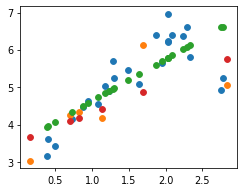

x=(24, 3),y=(24, 1),w=(3, 1), error=0.1551681918576002
x=(6, 3),y=(6, 1),w=(3, 1), error=0.17988883029647432


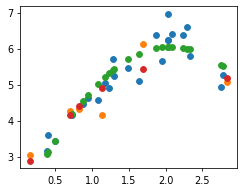

x=(24, 4),y=(24, 1),w=(4, 1), error=0.1015492320994963
x=(6, 4),y=(6, 1),w=(4, 1), error=0.11312405395600157


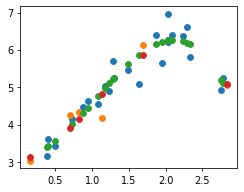

x=(24, 5),y=(24, 1),w=(5, 1), error=0.09403170739754448
x=(6, 5),y=(6, 1),w=(5, 1), error=0.0026860423291899826


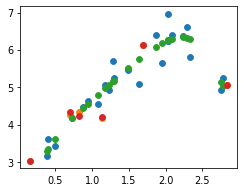

x=(24, 6),y=(24, 1),w=(6, 1), error=0.09403165039599498
x=(6, 6),y=(6, 1),w=(6, 1), error=3.816097192589958e-17


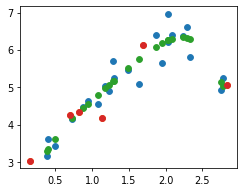

x=(24, 7),y=(24, 1),w=(7, 1), error=0.08519305344317651
x=(6, 7),y=(6, 1),w=(7, 1), error=2.8144063518208608e-15


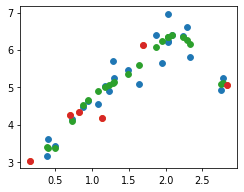

x=(24, 8),y=(24, 1),w=(8, 1), error=0.07579184168019822
x=(6, 8),y=(6, 1),w=(8, 1), error=1.0267010152150284e-14


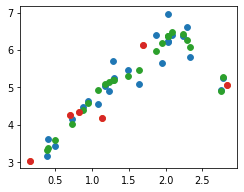

x=(24, 9),y=(24, 1),w=(9, 1), error=0.07488610990973395
x=(6, 9),y=(6, 1),w=(9, 1), error=1.7780280306717638e-15


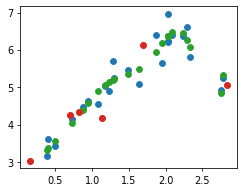

x=(24, 10),y=(24, 1),w=(10, 1), error=0.07489061288103582
x=(6, 10),y=(6, 1),w=(10, 1), error=4.1268737712322903e-13


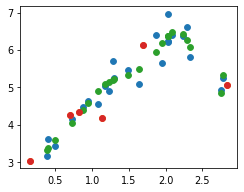

x=(24, 11),y=(24, 1),w=(11, 1), error=0.07423059799554273
x=(6, 11),y=(6, 1),w=(11, 1), error=1.1106139214894062e-14


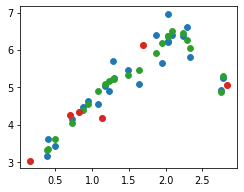

x=(24, 12),y=(24, 1),w=(12, 1), error=0.073284948830825
x=(6, 12),y=(6, 1),w=(12, 1), error=4.502743481989721e-12


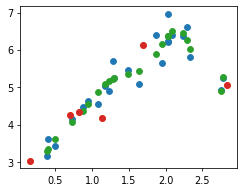

x=(24, 13),y=(24, 1),w=(13, 1), error=0.07256261989918773
x=(6, 13),y=(6, 1),w=(13, 1), error=5.323069778057865e-09


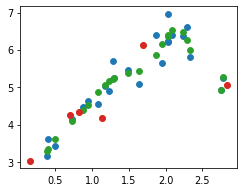

x=(24, 14),y=(24, 1),w=(14, 1), error=0.07316664577571322
x=(6, 14),y=(6, 1),w=(14, 1), error=4.9479774650691456e-09


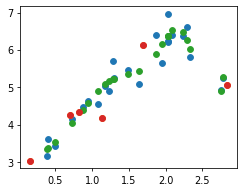

x=(24, 15),y=(24, 1),w=(15, 1), error=0.07271642229577506
x=(6, 15),y=(6, 1),w=(15, 1), error=8.737974929010356e-07


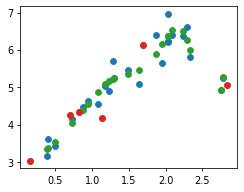

x=(24, 16),y=(24, 1),w=(16, 1), error=0.07261054667332045
x=(6, 16),y=(6, 1),w=(16, 1), error=0.005924917204663267


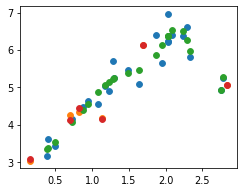

In [5]:
# Finally, plot the MSEs of train and test for varying degree of polynomial
# --- Compute Train and Test Errors for models ranging from linear to a polynomial of degree 15
# --------------------------------------------------------------------
# Lists to store MSEs for different polynomial degrees
train_errors_mse = []
test_errors_mse = []

train_errors_mse.clear()
test_errors_mse.clear()
for degree in range(1, 16):
    X_poly = make_polynomial(X_train, degree + 1)
    y_p, mse = run(X_poly, y_train)
    train_errors_mse.append(mse)

    X_poly_test = make_polynomial(X_test, degree + 1)
    y_p_test, mse_test = run(X_poly_test, y_test)
    test_errors_mse.append(mse_test)

    plt.figure(figsize=(4, 3), dpi=70)
    plt.scatter(X_train, y_train)
    plt.scatter(X_test, y_test)
    plt.scatter(X_train, y_p)
    plt.scatter(X_test, y_p_test)
    plt.show()

# for degree in range(1, 16):

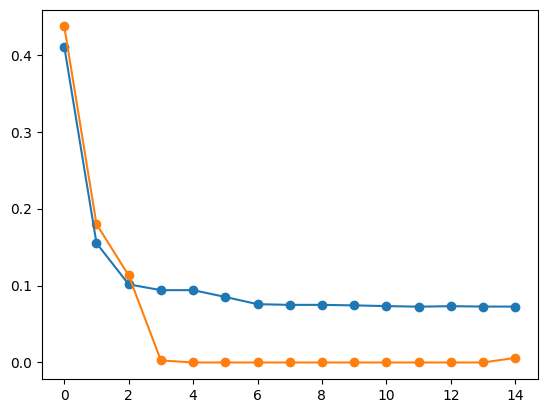

In [6]:
plt.scatter(range(0, 15), train_errors_mse)
plt.plot(range(0, 15), train_errors_mse)
plt.scatter(range(0, 15), test_errors_mse)
plt.plot(range(0, 15), test_errors_mse)